In [1]:
# 第2章｜Pyfolio 分析報酬率曲線：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1 pyfolio-reloaded==0.9.9
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# Pyfolio 分析報酬率曲線

**對應影片**：第 2 章 單元 6「Pyfolio 分析報酬率曲線」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 原版 `pyfolio` 已停止維護，在新版 pandas 上會出錯 | 改裝社群維護的 `pyfolio-reloaded`，`import pyfolio as pf` 與函式名稱都一樣 |
| 需要 `tz_localize('Asia/Taipei')` 與 `iteritems` 的相容修補 | 不需要任何修補 |
| 讀上一單元存的 pickle 檔 | 在這裡直接回測策略 |
| — | 另外介紹 FinLab 回測報告內建的績效統計 |

In [2]:
import warnings

import pyfolio as pf
from finlab.backtest import sim

warnings.filterwarnings('ignore')

## 1. 用 Pyfolio 看 0050 的報酬

Pyfolio 的輸入是「每日報酬率」。用還原收盤價計算，才會包含配息。

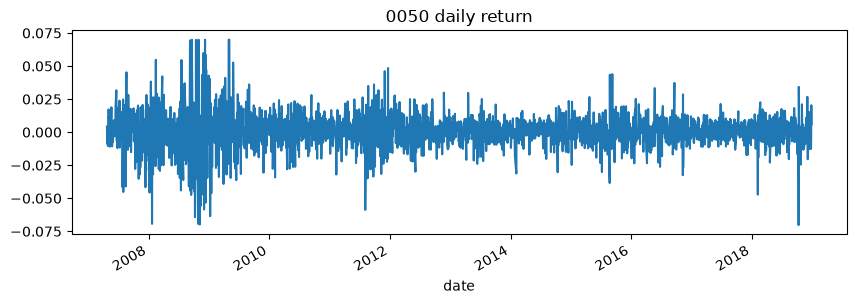

In [3]:
adj_close = data.get('etl:adj_close')
returns_0050 = adj_close['0050'].pct_change().dropna()
returns_0050.plot(figsize=(10, 3), title='0050 daily return');

Start date,2007-04-24
End date,2018-12-28
Total months,138
,Backtest
Annual return,5.79%
Cumulative returns,91.041%
Annual volatility,20.318%
Sharpe ratio,0.38
Calmar ratio,0.10
Stability,0.77
Max drawdown,-55.753%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,55.75,2007-10-29,2008-11-20,2011-01-28,850
1,23.01,2011-01-28,2011-12-19,2013-05-16,600
2,20.96,2015-04-27,2015-08-24,2016-08-08,336
3,15.99,2018-08-30,2018-12-26,NaT,NaN
4,14.55,2007-07-25,2007-08-16,2007-10-02,50


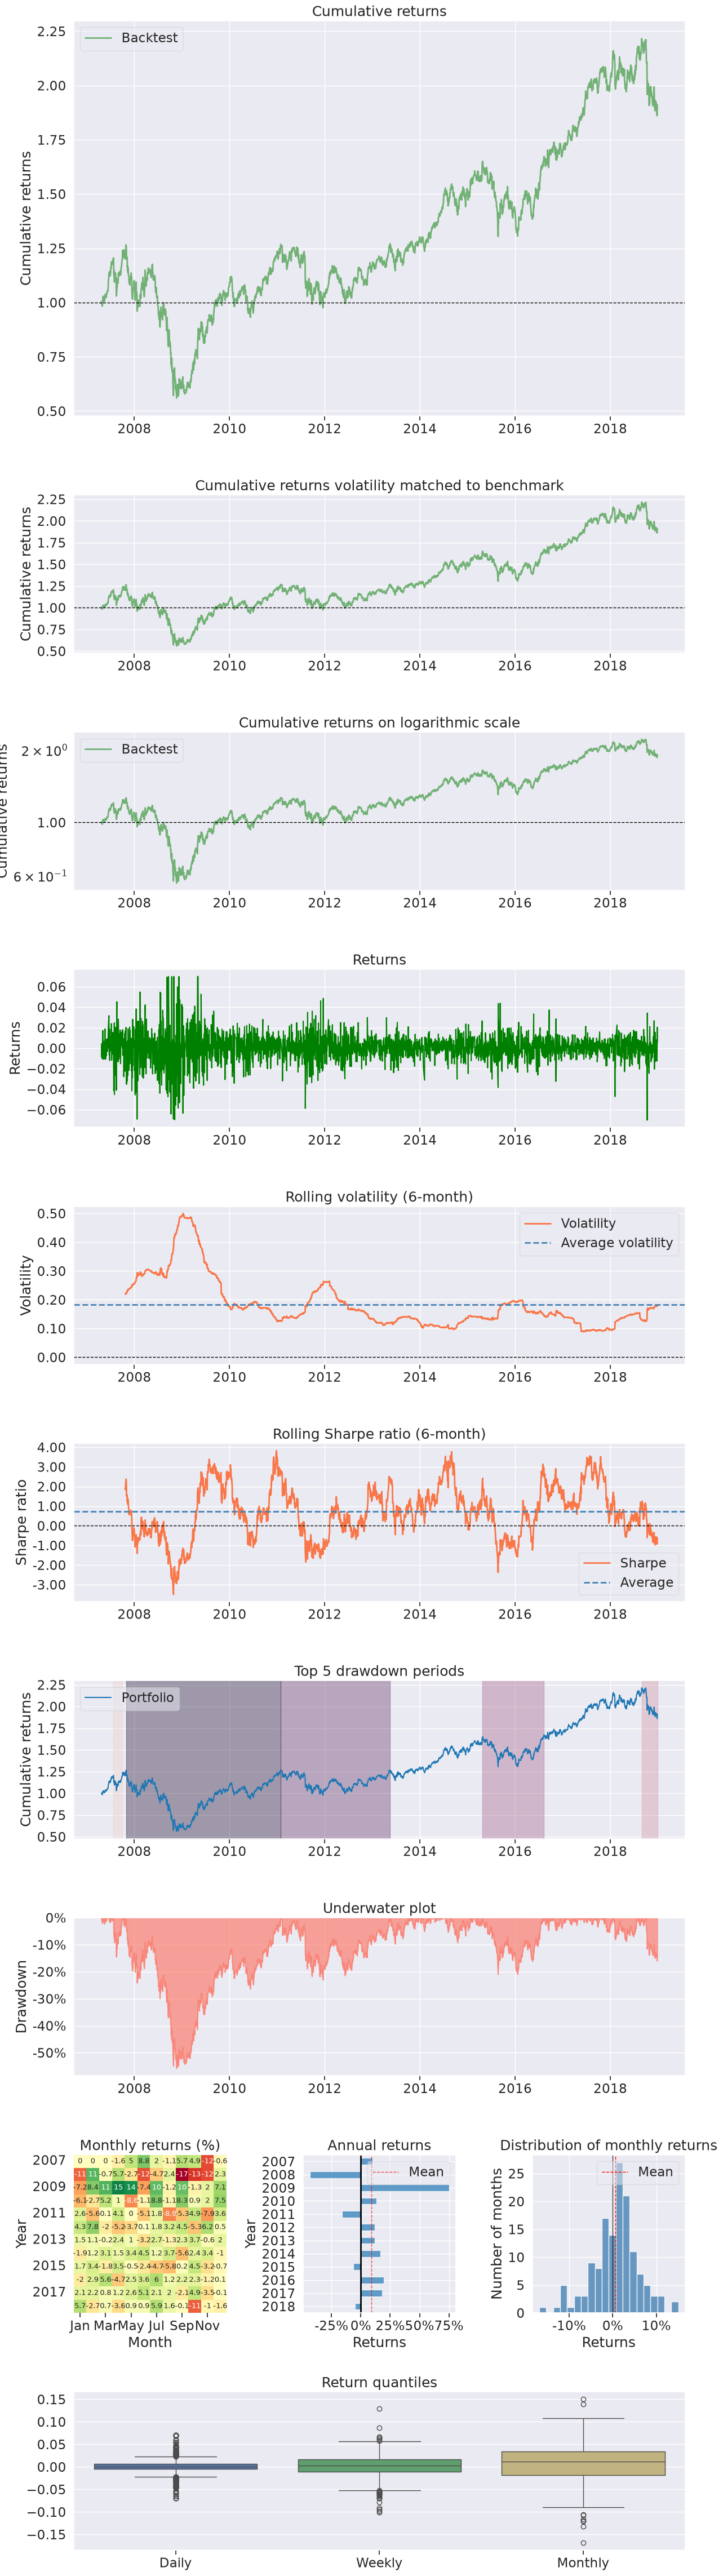

In [4]:
pf.create_returns_tear_sheet(returns_0050)

報表重點：

| 指標 | 意思 |
| --- | --- |
| Annual return | 年化報酬率 |
| Annual volatility | 年化波動度，越大代表淨值上下震盪越劇烈 |
| Sharpe ratio | 每承擔一單位波動換到多少報酬，越高越好 |
| Max drawdown | 最大回檔：從最高點跌下來最多跌了多少 |
| Underwater plot | 每一天距離歷史高點還差多少 |

## 2. 分析策略：K 線型態策略 vs 0050

重新回測上一個單元的三星十字策略，把回測的淨值曲線轉成每日報酬，交給 Pyfolio 並指定比較基準。

Start date,2007-05-17
End date,2018-12-28
Total months,137
,Backtest
Annual return,-3.231%
Cumulative returns,-31.313%
Annual volatility,25.956%
Sharpe ratio,0.00
Calmar ratio,-0.05
Stability,0.06
Max drawdown,-63.789%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,63.79,2007-07-25,2012-01-02,NaT,NaN
1,16.81,2007-05-22,2007-06-26,2007-07-02,30
2,6.26,2007-07-09,2007-07-11,2007-07-17,7
3,2.19,2007-07-18,2007-07-20,2007-07-24,5
4,1.37,2007-07-02,2007-07-03,2007-07-04,3


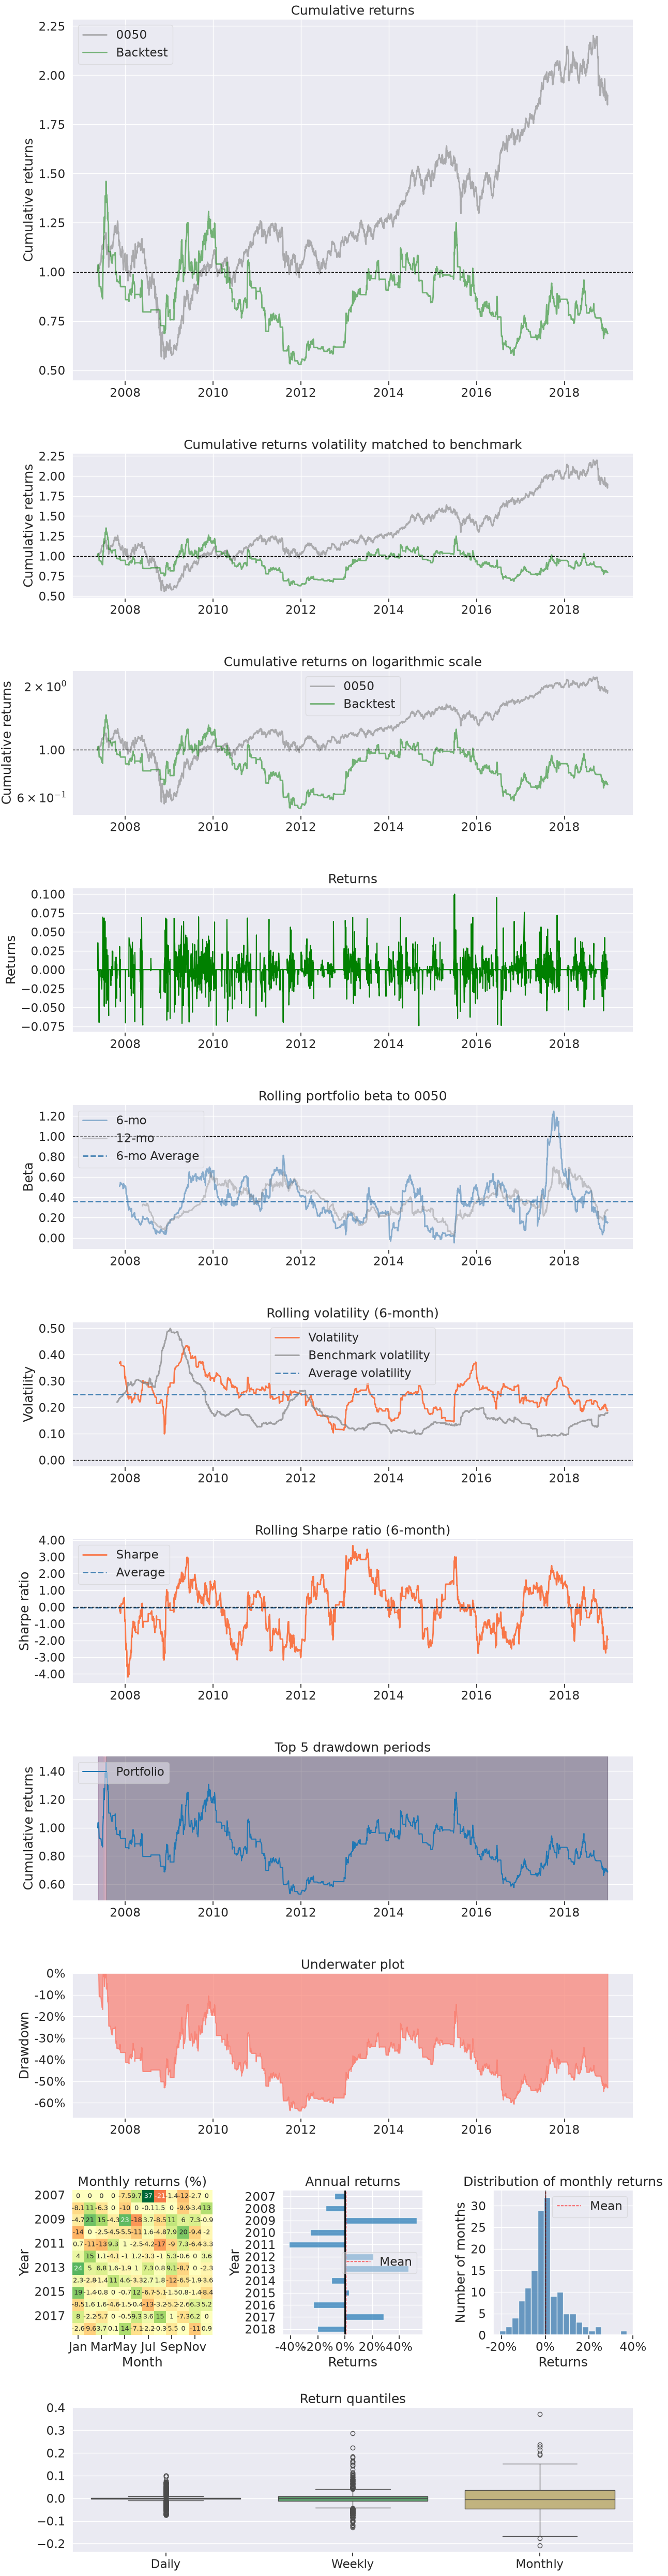

In [5]:
BULLISH = 100
N_STOCKS = 10
EXIT_MA_WINDOW = 20
LIQUIDITY_WINDOW = 20
MIN_AVG_VOLUME_SHARES = 500_000

close = data.get('price:收盤價')
avg_volume = data.get('price:成交股數').average(LIQUIDITY_WINDOW)

entries = (data.indicator('CDLTRISTAR') == BULLISH) & (avg_volume > MIN_AVG_VOLUME_SHARES)
exits = close < close.average(EXIT_MA_WINDOW)
report = sim(entries.hold_until(exits, nstocks_limit=N_STOCKS, rank=avg_volume), name='CDLTRISTAR')

strategy_returns = report.creturn.pct_change().dropna()
pf.create_returns_tear_sheet(strategy_returns, benchmark_rets=returns_0050)

## 3. FinLab 回測報告內建的統計

不裝 Pyfolio 也能看績效：`report.get_stats()` 回傳常用指標，`report.get_metrics()` 回傳更完整的分類指標。

In [6]:
stats = report.get_stats()
{key: stats[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe', 'daily_sortino', 'win_ratio', 'best_year', 'worst_year']}

{'cagr': -0.03180893512030902,
 'max_drawdown': -0.6378897461808306,
 'daily_sharpe': -0.07339448303372577,
 'daily_sortino': -0.11567180598146888,
 'win_ratio': 0.3311897106109325,
 'best_year': 0.5275361468633502,
 'worst_year': -0.4121442777354508}

In [7]:
metrics = report.get_metrics()
metrics['risk']

{'maxDrawdown': -0.6378897461808306,
 'avgDrawdown': -0.15094892010035818,
 'avgDrawdownDays': 704.5,
 'valueAtRisk': np.float64(-0.11799722045125727),
 'cvalueAtRisk': np.float64(-0.15447790754906926)}

執行 `report.display()` 可以看到 FinLab 的互動式回測報告（淨值曲線、每月報酬、持股明細）。
互動報表檔案較大，教材裡沒有保存它的輸出，請自己執行下一格查看。

In [8]:
report.display()